In [18]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table

import pandas as pd
import pyStarlet_master_2D1D as pys

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter1d

import torch

# DECLARE CONSTANTS

EVT_FILE = '3392/repro/acisf03392_repro_evt2.fits'
XMIN = 4110
XMAX = 4150
YMIN = 4050
YMAX = 4100

EMIN = 2000
EMAX = 6000

BINX = 64
BINY = 64
BINE = 100

VERBOSE = False

NUM_LVL = 2
LVL_START = 1

In [44]:
fsrc = 'output/source_0.fits'
hdu = fits.open(fsrc)
evt_data = hdu[1].data
header = fits.getheader(EVT_FILE, 2)
#del header["HISTORY"]
print(hdu[0].header)
print('\n'.join(header))

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H HDUNAME = 'PRIMARY '                                                            COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H ORIGIN  = 'ASC     '           / Source of FITS file                            CREATOR = 'acis_process_events - CIAO 4.

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / 8-bit bytes                                    NAXIS   =                    2 / 2-dimensional binary table                     NAXIS1  =                   82 / width of table in bytes                        NAXIS2  =              1230256 / number of rows in table                        PCOUNT  =                    0 / size of special data area                      GCOUNT  =                    1 / one data group (required keyword)              TFIELDS =                   20 / number of fields in each row                   EXTNAME = 'EVENTS  '           / name of this binary table extension            HDUNAME = 'EVENTS  '           / ASCDM block name                               TTYPE1  = 'time    '           / S/C TT corresponding to mid-exposure           TFORM1  = '1D      '           / format of field                                TUNIT1  = 's       '                    

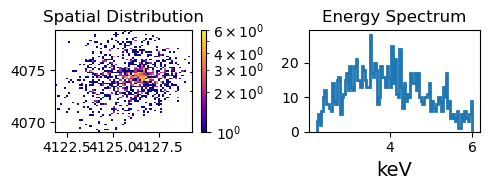

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

In [ ]:


cols = ['energy', 'x', 'y']
df = Table([evt_data[c] for c in cols], names=cols).to_pandas()

subset = df[(df['x'] > XMIN) & (df['x'] < XMAX) & \
            (df['y'] > YMIN) & (df['y'] < YMAX) & \
            (df['energy'] > EMIN) & (df['energy'] < EMAX)]

fig = plt.figure(figsize=(5, 2)) 
ax1 = fig.add_subplot(1, 2, 1)
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Spatial Distribution')
fig.colorbar(h2d[3], ax=ax1)

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(subset['energy']/1.e3, bins=BINE, histtype='step', lw=2)
ax2.set_xlabel('keV', size=14)
ax2.set_title('Energy Spectrum')

plt.tight_layout()
plt.show()
plt.figure(2, figsize=(4,4))

In [8]:
def starlet_cube(subset, lvl_start=LVL_START, num_lvl=NUM_LVL, include_raw=True):
    spectral_cube, edges = np.histogramdd(subset[['energy', 'x', 'y']].values, bins=(BINE, BINX, BINY))
    starlet_cube = pys.Starlet_Forward3D(spectral_cube,J=4)[:,:,:,lvl_start:lvl_start+num_lvl]

    ## Alllll the extra steps needed to add the raw energy level to this
    if include_raw:
        raw_energy_level = spectral_cube[..., np.newaxis]
        combined_cube = torch.from_numpy(np.concatenate([raw_energy_level, starlet_cube], axis=-1)).permute(0, 3, 1, 2)

    dims = ['energy', 'x', 'y']
    indices = []
    for i, col in enumerate(dims):
        # Find bin index (subtract 1 for 0-indexing)
        idx = np.digitize(subset[col].values, edges[i]) - 1
        # Clip to stay within cube boundaries
        idx = np.clip(idx, 0, starlet_cube.shape[i] - 1)
        indices.append(idx)
    e_idx, x_idx, y_idx = indices

    e_lvls = []

    if include_raw: e_lvls.append(['energy'])

    for lvl in range(num_lvl):
        subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]
        e_lvls.append(f'starlet_{lvl}')
    
    cube = starlet_cube
    if include_raw: cube = combined_cube

    return cube

In [9]:
starlet_cube(subset)

/tmp/ipykernel_27489/3569409934.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]
/tmp/ipykernel_27489/3569409934.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]


tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  2.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         [[-1.0953e-01,  1.2085e-02,  8.2153e-02,  ..., -3.0518e-04,
           -1.5259e-04, -7.6294e-05],
          [-3.0838e-02,  1.2653e-01,  1.9017e-01,  ..., -1.2207e-03,
           -6.1035e-04, -3.0518e-04],
          [ 1.6296e-02,  1.3553e-01,  1.5445e-01,  ..., -3.0518e-03,
           -1.5259e-03, -7.6294e-04],
          ...,
     

Background table size: 47512
Source table size: 16735


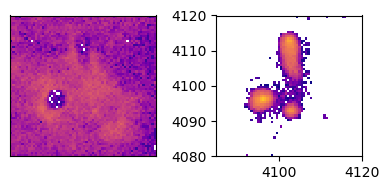

In [10]:
std_scaler = StandardScaler()
scaled_df = std_scaler.fit_transform(subset[['x', 'y', 'energy', 'starlet_0', 'starlet_1']])

NCOMP = 2
gmm = GaussianMixture(
    n_components=NCOMP,
    covariance_type='full',   # most flexible; try 'diag' if you want faster
    random_state=0
)

gmm.fit(scaled_df)
probs = gmm.predict_proba(scaled_df)
labels = gmm.predict(scaled_df) 

table_bg = subset[labels == 0][['energy', 'starlet_0', 'starlet_1', 'x', 'y']].copy()
table_source = subset[labels == 1][['energy', 'starlet_0', 'starlet_1', 'x', 'y']].copy()

table_bg['weight'] = probs[labels == 0, 0]
table_source['weight'] = probs[labels == 1, 1]

print(f"Background table size: {len(table_bg)}")
print(f"Source table size: {len(table_source)}")

VMIN = 0.5
VMAX = 1e3

fig = plt.figure(figsize=(2 * NCOMP, 2))

ax = plt.subplot(100 + 10 * NCOMP + 1)

h = ax.hist2d(
    table_bg['x'],
    table_bg['y'],
    bins=(BINX, BINY),
    range=[[XMIN, XMAX], [YMIN, YMAX]],
    weights=table_bg['weight'],
    cmap='plasma',
    norm=LogNorm(vmin=VMIN, vmax=VMAX)
)

ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

ax = plt.subplot(100 + 10 * NCOMP + 2)

h = ax.hist2d(
    table_source['x'],
    table_source['y'],
    bins=(BINX, BINY),
    range=[[XMIN, XMAX], [YMIN, YMAX]],
    weights=table_source['weight'],
    cmap='plasma',
    norm=LogNorm(vmin=VMIN, vmax=VMAX)
)

plt.tight_layout()

In [11]:
scaled_star_df = std_scaler.fit_transform(table_source[['x', 'y', 'energy']])

nb_source = 3
gmm = GaussianMixture(
    n_components=nb_source,
    covariance_type='full',   # most flexible; try 'diag' if you want faster
    random_state=0
)

gmm.fit(scaled_star_df)
probs2 = gmm.predict_proba(scaled_star_df)
labels2 = gmm.predict(scaled_star_df)

sources = []
for i in range(nb_source):
    sources.append(table_source[labels2 == i][['energy', 'x', 'y']].copy())
    sources[-1]['weight'] = probs2[labels2 == i, i]


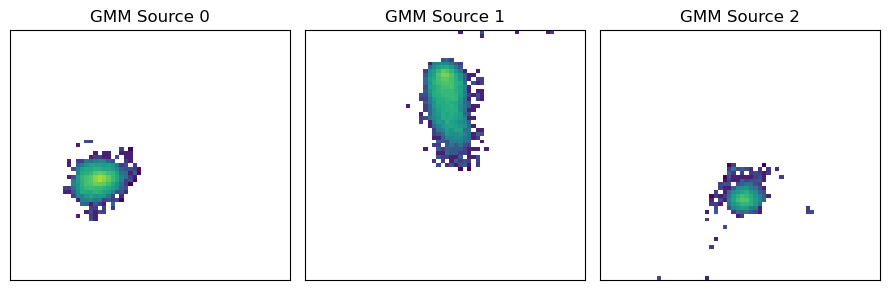

In [12]:
fig = plt.figure(figsize=(3 * nb_source, 3))

for i in range(nb_source):
    ax = plt.subplot(100 + 10 * nb_source + i + 1)

    h = ax.hist2d(
        sources[i]['x'],
        sources[i]['y'],
        bins=(BINX, BINY),
        range=[[XMIN, XMAX], [YMIN, YMAX]],
        weights=sources[i]['weight'],
        cmap='viridis',
        norm=LogNorm(vmin=VMIN, vmax=VMAX)
    )

    ax.set_title(f'GMM Source {i}')
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

plt.tight_layout()

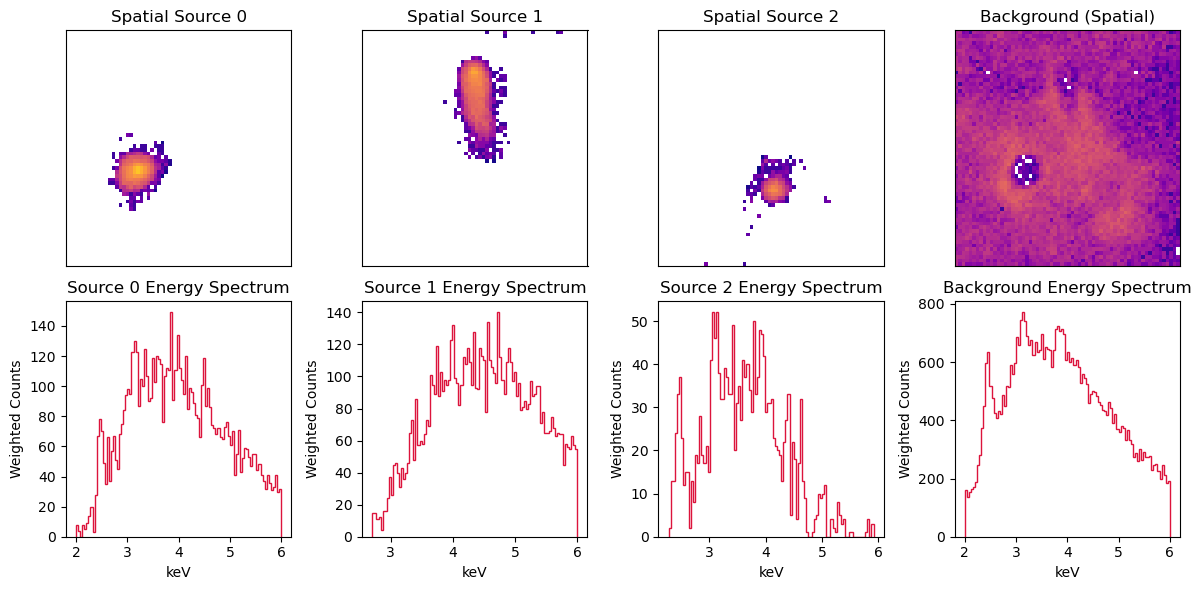

In [13]:
fig, axes = plt.subplots(2, nb_source + 1, figsize=(3 * (nb_source + 1), 6))

for i in range(nb_source):
    # --- ROW 1: SPATIAL (TOP) ---
    ax_top = axes[0, i]
    h = ax_top.hist2d(
        sources[i]['x'],
        sources[i]['y'],
        bins=(BINX, BINY),
        range=[[XMIN, XMAX], [YMIN, YMAX]],
        weights=sources[i]['weight'],
        cmap='plasma',
        norm=LogNorm(vmin=VMIN, vmax=VMAX)
    )
    ax_top.set_title(f'Spatial Source {i}')
    ax_top.xaxis.set_visible(False)
    ax_top.yaxis.set_visible(False)

    # --- ROW 2: SPECTRAL (BOTTOM) ---
    ax_bottom = axes[1, i]
    ax_bottom.hist(
        sources[i]['energy']/1e3,
        bins=BINE,
        histtype='step',
        color='crimson'
    )
    ax_bottom.set_title(f'Source {i} Energy Spectrum')
    ax_bottom.set_xlabel('keV')
    ax_bottom.set_ylabel('Weighted Counts')

ax = axes[0, -1]
h = ax.hist2d(
    table_bg['x'],
    table_bg['y'],
    bins=(BINX, BINY),
    range=[[XMIN, XMAX], [YMIN, YMAX]],
    cmap='plasma',
    norm=LogNorm(vmin=VMIN, vmax=VMAX)
)
ax.set_title(f'Background (Spatial)')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

ax_bottom = axes[1, -1]
ax_bottom.hist(
    table_bg['energy']/1e3,
    bins=BINE,
    weights=table_bg['weight'],
    histtype='step',
    color='crimson'
)
ax_bottom.set_title(f'Background Energy Spectrum')
ax_bottom.set_xlabel('keV')
ax_bottom.set_ylabel('Weighted Counts')

plt.tight_layout()
plt.show()